In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from src import get_alphabet
from src.features import get_additive_features
from src.fixers.fix_additive_model import fix_additive_model
from src._test_gauge_fixing import _test_gauge_fixing
from src.seq_embedder import SeqEmbedder


In [2]:
# Plot parameters
def plot_additive_thetas(theta_series, fixed_theta_series):
    for order in range(2)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=81
000 f=0.931293 	 f_fixed=0.931293
001 f=-0.115337 	 f_fixed=-0.115337
002 f=-4.171781 	 f_fixed=-4.171781
003 f=1.823087 	 f_fixed=1.823087
004 f=-2.561128 	 f_fixed=-2.561128
005 f=-4.026564 	 f_fixed=-4.026564
006 f=2.332353 	 f_fixed=2.332353
007 f=-1.516489 	 f_fixed=-1.516489
008 f=-5.197436 	 f_fixed=-5.197436
009 f=-4.630968 	 f_fixed=-4.630968
Tested 10 random sequences; all seqs passed.
features match: True


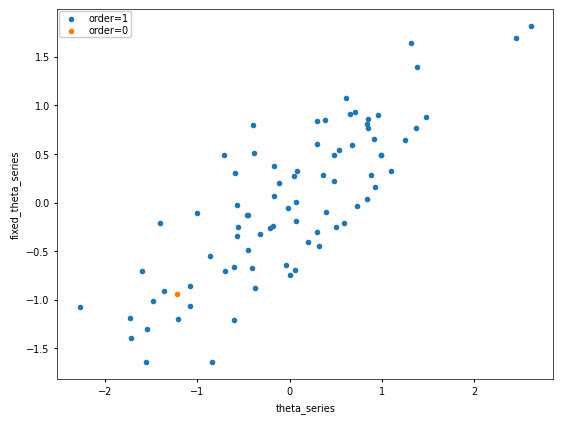

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_additive_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_additive_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Create embedder
embedder = SeqEmbedder(features=features, 
                       L=L)

# Test result
_test_gauge_fixing(theta_series=theta_series, 
                   theta_fixed_series=fixed_theta_series, 
                   L=L, 
                   alphabet=alphabet, 
                   embedder=embedder,
                   num_trials=10)

# Plot resulting parameters
plot_additive_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
from src.evaluate_model_on_seqs import evaluate_model_on_seqs
from itertools import product

random_seqs = [''.join(random.choices(alphabet, k=L)) for _ in range(100)]
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs,
                       embedder=embedder)

array([ -0.86796693,  -1.84905342,  -4.60081754,  -0.51037354,
        -1.9177229 ,  -3.31264375,   3.62600862,  -1.74609742,
        -2.94618899,  -7.53042663,  -2.52652358,  -4.616844  ,
         0.57213722,  -3.90973777,  -4.18076172,   4.77905167,
         3.92374498,   1.16652629,  -3.69542169,   4.43270966,
        -1.76589606,   7.24429662,   1.26650752,   1.12066358,
        -1.81405588,  -0.17359308,  -7.42169898,   1.48200821,
         2.63313544,  -2.08600224,   3.15396412,  -0.54802532,
        -4.83159081,  -2.52574914,   1.46321356,   1.15679963,
        -1.33439197,  -1.01063606,   4.66640943,  -1.22901618,
         6.38473724,  -0.58145338,   3.46676108,   3.84399793,
        -4.61574991,  -2.59680429,  -2.72780743,   5.38585586,
        -4.48731742,   1.16723799,   1.62701481,   1.85707524,
        -1.14675131,   6.7772978 ,  -1.05057687,  -6.19499327,
         2.66186242,  -0.60944265,   8.53881725,  -3.73129425,
        -2.73448219,  -2.86064506,  -0.58513654,  -5.64